Fonte: https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/

https://medium.com/@nara.guimaraes/regress%C3%A3o-log%C3%ADstica-como-usu%C3%A1-la-em-an%C3%A1lise-de-dados-3fdb6be3a255

Ao contrário da regressão linear que prevê valores contínuos, ela prevê a probabilidade de uma entrada pertencer a uma classe específica. É usado para classificação binária onde a saída pode ser uma das duas categorias possíveis, como "Sim/Não", "Verdadeiro/Falso", "1/0". 
 
Será que poderiamos dizer, com algum grau de certeza, se alguém sobreviveu ou não ao Titanic sabendo apenas algumas informações como sexo, idade, classe?

Vamos construir o raciocínio do algoritmo.

**1. Ponderando as Evidências**

Primeiro, o algoritmo precisa aprender com os dados históricos dos passageiros. A Regressão logística faz isso atribuindo um "peso" a cada informação. Esse peso representa a importância e a direção daquela característica na chance de sobrevivência.

Por exemplo, se fosse para chutar:

- **Sexo = Feminino:** Receberia um peso positivo ou negativo? será que ser mulher afetaria a chance de sobrevivência de uma pessoa no dia do titanic?

- **Classe = 1ª:** Aumentaria a probabilidade de ter acesso a um bote salva vidas, talvez?

- **Classe = 3ª:** Bom, se ser da 1ª seria um valor positivo, esse imagino que deve ter um sinal negativo então, estar na terceira classe diminuía sua chance de sobreviver, faz sentido?

- **Idade:** Imagino que pessoas mais velhas diminua um pouco as chances, então talvez seja negativo, quanto mais velho menor é a probabilidade de sobrevivência.

*(note que eu pulei a classe 2)*

Para cada novo passageiro, o algoritmo calcula um "score de sobrevivência" combinando suas características com os pesos aprendidos.

- **Score_Sobrevivência = (Peso_sexo x Valor_Sexo) + (Peso_Classe x Valor_Classe) + (Peso_Idade x Valor_Idade) + ...**

Este é o **log-odds**, um número único que resume toda a evidência.

- Logodds positivos -> Probabilidade maior que 0.5
- Logodds negativos -> probabilidade menor que 0.5

**2. Função Logística**

Por mais que o log-odds é interessante, ele não é intuitivo. Precisamos ir atrás de uma probabilidade: um número claro entre 0% e 100%

É aqui que entra a Função Logística (ou Sigmoide):

- Ela pega o score (de $-\infin$ a $\infin$) e transforma em um valor entre 0 e 1

A intuiçlão é a seguinte:

- Score muito alto é convertido em uma prob. perto de 1 

- Score muito baixo é convertido em uma prob. perto de 0

- Score igual a zero é convertido para 0.5

![Função sigmoide (logística)](https://upload.wikimedia.org/wikipedia/commons/8/88/Logistic-curve.svg)

** 3. Classificação**

Agora, para cada passageiro, temos uma probabilidade clara. Para fazer a classificação final, estabelecemos um limiar de decisão (default 50%)

- Se Prob. de sobrevivência > 0.5, o modelo prevê que o passageiro Sobreviveu (1)

- (0), cc.


### 3.3.2 Intuição 

Agora, vamos analisar os dados do naufrágio do Titanic em 1912. 
Você tem informações sobre um passageiro desconhecido:

- Idade: 22 anos
- Classe: 3ª classe 
- Sexo: Masculino

Pergunta: **O Jack sobreviveu ou não sobreviveu ao naufrágio?**


In [11]:
# ==================================================
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  "Titanic-Dataset.csv",
  pandas_kwargs={"encoding": "latin", "usecols": [1, 2, 4, 5]}
)
# ==================================================

In [12]:
import pandas as pd

In [13]:
#=================================================  
# Análise exploratória
#=================================================

print(f"Dataset shape: {df.shape}")
print("---" * 20)
print(f"\nDataset columns: {df.columns.tolist()}")
print("---" * 20)
print(f"\nDataset info:")
df.info()

print("---" * 20)
print(f"\nDataset description:")
print(df.describe())
print("---" * 20)

Dataset shape: (891, 4)
------------------------------------------------------------

Dataset columns: ['Survived', 'Pclass', 'Sex', 'Age']
------------------------------------------------------------

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 28.0+ KB
------------------------------------------------------------

Dataset description:
         Survived      Pclass         Age
count  891.000000  891.000000  714.000000
mean     0.383838    2.308642   29.699118
std      0.486592    0.836071   14.526497
min      0.000000    1.000000    0.420000
25%      0.000000    2.000000   20.125000
50%      0.000000    3.000000   28.000000
75%   

In [14]:
# Sobrevivência por categoria

survival_by_sex = df.groupby("Sex")["Survived"].agg(["mean", "count"])
survival_by_sex["mean"] *= 100  
print(survival_by_sex)

print("---" * 20)

survival_by_class = df.groupby("Pclass")["Survived"].agg(["mean", "count"])
survival_by_class["mean"] *= 100
print(survival_by_class)

print("---" * 20)

df['Age_group'] = pd.cut(df['Age'], bins=[0, 16, 35, 60, 100], 
                         labels=['Child(0-16)', 'Young Adult(17-35)', 'Adult(36-60)', 'Senior(61+)'])

survival_by_age = df.groupby("Age_group", observed=True)["Survived"].agg(["mean", "count"])
survival_by_age["mean"] *= 100
print(survival_by_age)

print("---" * 20)



             mean  count
Sex                     
female  74.203822    314
male    18.890815    577
------------------------------------------------------------
             mean  count
Pclass                  
1       62.962963    216
2       47.282609    184
3       24.236253    491
------------------------------------------------------------
                         mean  count
Age_group                           
Child(0-16)         55.000000    100
Young Adult(17-35)  38.287154    397
Adult(36-60)        40.000000    195
Senior(61+)         22.727273     22
------------------------------------------------------------


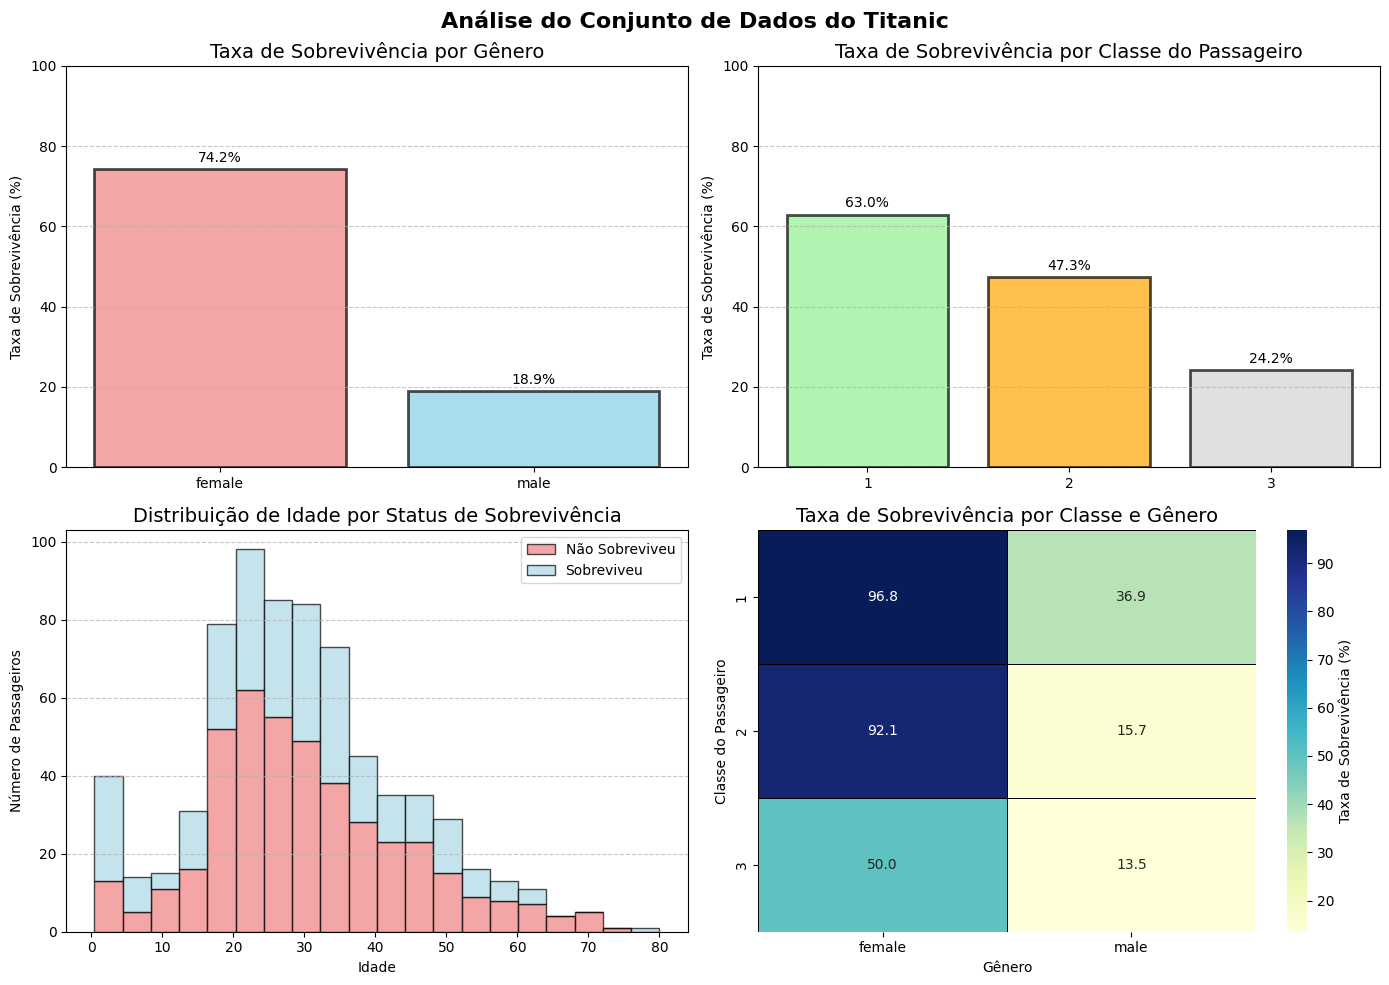

In [15]:
# Visualizações
# ==================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle('Análise do Conjunto de Dados do Titanic', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
survival_sex = df.groupby('Sex')['Survived'].mean() * 100
bars = ax1.bar(survival_sex.index, survival_sex.values, color=['lightcoral', 'skyblue'], alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Taxa de Sobrevivência (%)')
ax1.set_ylim(0, 100)
ax1.set_title('Taxa de Sobrevivência por Gênero', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom')

ax2 = axes[0, 1]
survival_class = df.groupby('Pclass')['Survived'].mean() * 100
bars = ax2.bar(survival_class.index.astype(str), survival_class.values, color=['lightgreen', 'orange', 'lightgrey'], alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Taxa de Sobrevivência (%)')
ax2.set_ylim(0, 100)
ax2.set_title('Taxa de Sobrevivência por Classe do Passageiro', fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom')

ax3 = axes[1, 0]
survived = df[df['Survived'] == 1]['Age']
died = df[df['Survived'] == 0]['Age']
ax3.hist([died, survived], bins=20, stacked=True, color=['lightcoral', 'lightblue'], edgecolor='black', alpha=0.7)
ax3.set_xlabel('Idade')
ax3.set_ylabel('Número de Passageiros')
ax3.set_title('Distribuição de Idade por Status de Sobrevivência', fontsize=14)
ax3.legend(['Não Sobreviveu', 'Sobreviveu'])
ax3.grid(axis='y', linestyle='--', alpha=0.7)

ax4 = axes[1, 1]
pivot = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
sns.heatmap(
    pivot * 100, annot=True, fmt=".1f",
    cmap='YlGnBu', cbar_kws={'label': 'Taxa de Sobrevivência (%)'},
    ax=ax4, linewidths=.5, linecolor='black'
)
ax4.set_title('Taxa de Sobrevivência por Classe e Gênero', fontsize=14)
ax4.set_ylabel('Classe do Passageiro')
ax4.set_xlabel('Gênero')

plt.tight_layout()
plt.show()

Note algumas coisas:

- Mulheres tiveram uma taxa de 74.2% de sobrevivência vs 18.9% dos homens

- Passageiros da 1ª classe: 63.0% de sobrevivência

- Passageiros da 3ª classe: 24.2% de sobrevivência

- Crianças (0-16 anos): 55% de sobrevivência

Parece que mulheres e crianças primeiro era real


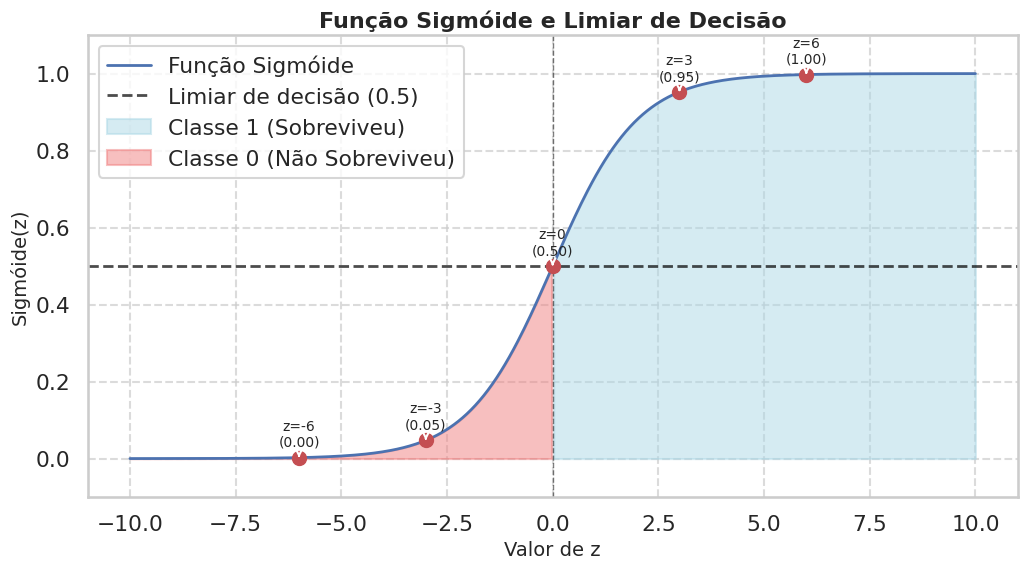

In [ ]:
# =================================================
# Entendendo a sigmóide
# =================================================

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 400)
sigmoid_values = sigmoid(z_values)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(z_values, sigmoid_values, 'b-', linewidth=2, label='Função Sigmóide')
ax.axhline(0.5, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Limiar de decisão (0.5)')
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.fill_between(z_values, 0, sigmoid_values, where=(sigmoid_values >= 0.5), color='lightblue', alpha=0.5, label='Classe 1 (Sobreviveu)')
ax.fill_between(z_values, 0, sigmoid_values, where=(sigmoid_values < 0.5), color='lightcoral', alpha=0.5, label='Classe 0 (Não Sobreviveu)')

examples = [
    (-6, sigmoid(-6), "z=-6"), (-3, sigmoid(-3), "z=-3"), (0, sigmoid(0), "z=0"), (3, sigmoid(3), "z=3"), (6, sigmoid(6), "z=6")
]

for z, s, label in examples:  
    ax.plot(z, s, 'ro', markersize=10)
    ax.annotate(f'{label}\n({s:.2f})', xy=(z, s), xytext=(z, s + 0.03),
                arrowprops=dict(facecolor='wheat', arrowstyle='->'),
                fontsize=10, ha='center')

ax.set_title('Função Sigmóide e Limiar de Decisão', fontsize=16, fontweight='bold')
ax.set_xlabel('Valor de z', fontsize=14)
ax.set_ylabel('Sigmóide(z)', fontsize=14)
ax.set_ylim(-0.1, 1.1)
ax.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()


### 3.3.3 Formulação Formal

**Log-Odds (Logit)**

A odd de um evento é a razão entre a probabilidade de ele ocorrer $(p)$ e a probabilidade de não ocorrer $(1-p)$

$ Odds = \frac{p}{1-p}$

A Regressão Logística assume que o logaritmo da odd (**log-odds ou logit**) é uma função linear das features:

$\ln \left(\frac{p}{1-p}\right) = \mathbf{w}^T\mathbf{x}+b$

Onde $\mathbf{w}$ e $\mathbf{x}$ são os vetores de pesos e features respectivamente.

Note que, ao isolar $p$ na equação, obtemos exatamente a função sigmoide.

**Entrada**

1. Conjunto de treinamento de n amostra em pares $D=\{(x^{(1)}, y^{(1)}), (x^{(2)}, x^{(i)}), ..., x^{(n)}, y^{(n)}\}$

    onde:

    - $x^{(i)}$: vetor de d features ($x^{(i)} = (x^{(i)}_1, x^{(i)}_2, ..., x^{(i)}_d)$), também adicionamos o termo de intercepto $x_0{(i)} = 1$, portanto $x^{(i)} \in \mathbb{R}^{d+1}$

    - $y^{(i)}$: rótulo de classe binário, ou seja, $y^{(i)} \in \{0,1\}$



**Processamento**

O processamento aqui consiste em aprender um vetor de parâmetro (pesos) $\mathbf{w} \in \mathbb{R}^{d+1}$ que melhor mapeia as entradas $x$ para saídas $y$

**1. Log Loss**

Para uma única amostra de treinamento (x, y) a função custo é definida como:

$L(\hat{p}, y) = -[y\log{(\hat{p})}+(1-y)log(1-\hat{p})]$

Essa função penaliza as predições erradas:

- Se a classe real é $y=1$, a perda é $-log(\hat{p})$ se o modelo prevê \hat{p} -> 0, a perda tende a $\infin$

- Se a classe real é $y=0$, a perda é $-log(1-\hat{p})$ se o modelo prevê \hat{p} -> 1, a perda tende a $\infin$

A função custo total $J(\mathbf{w}, b)$ para o conjunto de dados inteiro é a média das perdas individuais:

$J(\mathbf{w}, b) = -\frac{1}{n}\sum^n_{i=1}[y^{(i)}\log{(h_{\mathbf{w}, b}(x^{(i)}))} + (1-y^{(i)})\log{(1-h_{\mathbf{w}, b}(x^{(i)}))}]$

Assim encontramos um mínimo global a partir dela

**2. Otimização**

Para minimizar $J(\mathbf{w}, b)$, utilizamos o algoritmo Gradiente Descendente. Ele atualiza iterativamente os parâmetros na direção oposta ao gradiente da função de custo.

As CPOs da função de custo em relação a cada peso $w_j$ e ao bias b são:

1: $\frac{\partial J}{\partial w_j} = \frac{1}{n}\sum^n_{i=1}(h_{\mathbf{w}, b}(x^{(i)}) - y^{(i)})x_j^{(i)}$

2: $\frac{\partial J}{\partial b} = \frac{1}{n}\sum^n_{i=1}(h_{\mathbf{w}, b}(x^{(i)}) - y^{(i)})$

As regras de atualização a cada iteração são:

$w_j := w_j - \alpha\frac{\partial J}{\partial w_j}$

$b := b - \alpha\frac{\partial J}{\partial b}$

onde $\alpha$ é chamado de (learning rate)

**Saída - Classificação**

- **Parâmetros do Modelo**: Um vetor de pesos $mathbb{w}$ e um bias $b$ otimizados

- **Predição**: Para uma nova amostra $x^o$, o modelo calcula a probabilidade $\hat{p} = \sigma (\mathbf{w}^T x^o + b)$

- **Classificação**: Um limiar de decisão (threshold), e.g. 0.5, é aplicado à probabilidade para obter a classe final:

$\hat{y} = 
\begin{cases}
1, & \text{se } \hat{p} \geq 0.5 \\
0, & \text{se } \hat{p} < 0.5
\end{cases}
$

**Considerações**

1. Interpretação dos Coeficientes: 

- Os pesos ($w_j$) podem ser interpretados de forma intuitiva, quando exponenciados, obtemos a razão de chances:

    - Para cada aumento de uma unidade em $x_j$, as odds do resultado ser $y=1$ é multiplicada por $\mathbb{e}^{w_j}$

2. Fronteira de Decisão (Decision Boundary)

A fronteira de decisão é a superficie que separa as classes. No caso da Regressão logística, ela ocorre onde a probabilidade é exatamente 0.5, como vimos, o que corresponde a $z=\mathbf{w}^T + b = 0$. Note que a fronteira de deciçao da Regressão Logística é linear

3. Regularização (L1 e L2)

Para evitar overfitting, especialmente com um grande número de features, fazemos o seguinte:

- **Ridge (L2)**: Adiciona $\frac{\lambda}{2n} \sum^d_{j=1}w^2_j$ para penalizar pesos grandes

- **Lasso (L1)**: Adiciona $\frac{\lambda}{n} \sum^d_{j=1}|w_j|$ para forçar os pesos a se tornaerem exatamente zero

- Saiba mais: [Regularization: avoiding overfitting](https://medium.com/@rithpansanga/logistic-regression-and-regularization-avoiding-overfitting-and-improving-generalization-e9afdcddd09d)

4. Extensão para Classificação Multiclasse (Regressão Softmax)

- Regressão Logística pode ser generalizada para problemas com mais de duas classes através da regressão softmax. Ela usa a função Softmax, em vez da sigmoide, para calcular a probabilidade de cada uma das $K$ classes

    - $P(y=k|x) = \frac{e^{z_k}}{\sum^K_{j=1}e^z_j}$

- Saiba mais: [Softmax Regression](https://rasbt.github.io/mlxtend/user_guide/classifier/SoftmaxRegression/#:~:text=Softmax%20Regression%20(synonyms%3A%20Multinomial%20Logistic,the%20classes%20are%20mutually%20exclusive).)

### 3.3.4 Desafio: "From Scratch"

Vamos implementar o algoritmo de Regressão Logística do zero

In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Inicializa o modelo de Regressão Logística.

        Parâmetros:
        -----------
        learning_rate: float
            α para o gradiente descendente.
        n_iterations: int
            Número de iterações do gradiente descendente.

        """
        pass


    def _add_intercept(self, X):
        """
        Adiciona uma coluna de intercepto (bias) aos dados de entrada.

        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.

        Retorna:
        --------
        np.ndarray
            Matriz de características com a coluna de intercepto adicionada.
        """
        pass


    def _sigmoid(self, z):
        """
        Aplica a função sigmóide.

        Parâmetros:
        -----------
        z: np.ndarray
            Valor ou matriz de valores para aplicar a função sigmóide.

        Retorna:
        --------
        np.ndarray
            Valor(es) transformados pela função sigmóide.
        """
        pass

    def _compute_cost(self, h, y):
        """
        Calcula a função de custo (loss).

        Parâmetros:
        -----------
        h: np.ndarray
            Saídas do modelo (valores previstos).
        y: np.ndarray
            Rótulos verdadeiros.

        Retorna:
        --------
        float
            Valor da função de custo.
        """
        pass

    def fit(self, X, y):
        """
        Treina o modelo de Regressão Logística usando gradiente descendente.

        Processo: 
        1. Adiciona a coluna de intercepto aos dados de entrada.
        2. Inicializa os pesos.
        3. Para cada iteração:
              a. Calcula as previsões (h).
              b. Calcula a função de custo (loss).
              c. Calcula o gradiente.
              d. Atualiza os pesos.
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Rótulos verdadeiros.
        """
        pass

    def predict_proba(self, X):
        """
        Faz previsões de probabilidade para os dados de entrada.

        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.

        Retorna:
        --------
        np.ndarray
            Probabilidades previstas para cada classe.
        """
        pass
    
    def predict(self, X, threshold=0.5):
        """
        Faz previsões de classe para os dados de entrada com base em um limiar.

        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        threshold: float
            Limiar para classificar as previsões.

        Retorna:
        --------
        np.ndarray
            Classes previstas (0 ou 1).
        """
        pass

    def score(self, X, y, threshold=0.5):
        """
        Calcula a acurácia do modelo.

        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Rótulos verdadeiros.
        threshold: float
            Limiar para classificar as previsões.

        Retorna:
        --------
        float
            Acurácia do modelo.
        """
        pass

In [ ]:
# Dados para Teste
# ==================================================
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  "Titanic-Dataset.csv",
  pandas_kwargs={"encoding": "latin", "usecols": [1, 2, 4, 5]}
)

X = df[['Pclass', 'Sex', 'Age']].values
y = df['Survived'].values


### 3.3.5 Usando SKlearn

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

In [18]:
# Carregando os dados (denovo)
# ==================================================
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  "Titanic-Dataset.csv",
  pandas_kwargs={"encoding": "latin", "usecols": [1, 2, 4, 5]}
)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].mean())
X = df[['Pclass', 'Sex', 'Age']].values
y = df['Survived'].values

print(f"Total de amostras: {X.shape[0]}")
print(f"Taxa de sobreviventes: {np.mean(y)*100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Total de amostras: 891
Taxa de sobreviventes: 38.38%


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.pipeline import Pipeline

In [ ]:
# =================================================
# 1. Básico

# idéia:
# - Normalizar features (IMPORTANTE)

# - Treinar o modelo
# =================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)


print(f"Acurácia: {accuracy*100:.2f}%")

Acurácia: 81.01%


In [25]:
# ================================================= 
# 2. Parâmetros Importantes

# penalty (default='l2')
# - 'l1': Lasso regularization
# - 'l2': Ridge regularization
# - 'elasticnet': Combination of L1 and L2
# - None: No regularization

# C (default=1.0)
# - Inverse of regularization strength; smaller values specify stronger regularization.

# solver (default='lbfgs')
# - algorithms for optimization
# - 'lbfgs': default, good for most cases
# - 'liblinear': good for small datasets and L1 regularization
# - 'newton-cg', 'sag', 'saga': good for large datasets

# class_weight (default=None)
# - 'balanced': Adjust weights inversely proportional to class frequencies
# - dict: Specify weights for each class
# - None: All classes have weight one
# ================================================= 

configs = [
    {'penalty': 'l2', 'C': 1.0, 'solver': 'lbfgs', 'class_weight': None},
    {'penalty': 'l1', 'C': 0.5, 'solver': 'liblinear', 'class_weight': 'balanced'},
    {'penalty': 'elasticnet', 'C': 0.1, 'solver': 'saga', 'class_weight': None, 'l1_ratio': 0.5},
    {'penalty': None, 'solver': 'lbfgs', 'class_weight': None}
]

for i, config in enumerate(configs, 1):
    lr_temp = LogisticRegression(**config, max_iter=1000, random_state=42)
    lr_temp.fit(X_train_scaled, y_train)
    acc = lr_temp.score(X_test_scaled, y_test)

    config_str = ', '.join(f"{k}={v}" for k, v in config.items())
    print(f"{i}. {config_str}")
    print(f"   Acurácia: {acc*100:.2f}%\n")

1. penalty=l2, C=1.0, solver=lbfgs, class_weight=None
   Acurácia: 81.01%

2. penalty=l1, C=0.5, solver=liblinear, class_weight=balanced
   Acurácia: 80.45%

3. penalty=elasticnet, C=0.1, solver=saga, class_weight=None, l1_ratio=0.5
   Acurácia: 79.89%

4. penalty=None, solver=lbfgs, class_weight=None
   Acurácia: 81.01%



Fonte: [sklearn - LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) 